# 02a — Diagnostikk og modellvurdering

Denne notebooken samler diagnostiske tester som begrunner modellvalgene i oppgaven. Fokus er på fire spørsmål:

1. Er sentrale serier stasjonære i nivå eller først differanse?
2. Er `cons_NO4` plausibelt endogen i prisligningen?
3. Har OLS-residualene problemer med seriekorrelasjon, heteroskedastisitet eller svak funksjonsform?
4. Finnes det tegn til enkel ikke-linearitet som støtter bruk av XGBoost og regimesensitive modeller?

Instrumentdelen under er eksplorativ diagnostikk. Temperatur og nedbør kan være relevante instrumentkandidater for forbruk, men eksogenitet må fortsatt forsvares faglig i teksten.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf

from src.config import C1, C3, FIG_DIR, INTERMEDIATE_DIR, OLS_FEATURES, TARGET, apply_style
from src.diagnostics import (
    control_function_endogeneity_test,
    fit_ols,
    functional_form_comparison,
    residual_diagnostics,
    stationarity_test_table,
    vif_table,
)

warnings.filterwarnings("ignore")
apply_style()

FIG_PATH = os.path.join(FIG_DIR, "02a")
os.makedirs(FIG_PATH, exist_ok=True)
os.makedirs(INTERMEDIATE_DIR, exist_ok=True)

In [2]:
df_processed = pd.read_parquet(f"{INTERMEDIATE_DIR}df_processed.parquet")
df_iso = pd.read_parquet(f"{INTERMEDIATE_DIR}df_iso.parquet")

print(f"Prosessert datasett: {df_processed.shape[0]:,} timer og {df_processed.shape[1]} kolonner")
print(f"ISO-datasett:        {df_iso.shape[0]:,} timer og {df_iso.shape[1]} kolonner")
display(df_iso[[TARGET, "cons_NO4", "fill_avvik", "prod_wind_NO4", "temp_NO4", "precip_NO4"]].head())

Prosessert datasett: 53,394 timer og 41 kolonner
ISO-datasett:        34,916 timer og 76 kolonner


,price_NO4,cons_NO4,fill_avvik,prod_wind_NO4,temp_NO4,precip_NO4
Delivery Start (CET),,,,,,
2020-01-01 00:00:00,283.87,2357.0,-0.158577,151.0,1.3,3.8
2020-01-01 01:00:00,280.62,2348.0,-0.158577,127.0,1.3,3.8
2020-01-01 02:00:00,275.19,2298.0,-0.158577,107.0,1.3,3.8
2020-01-01 03:00:00,271.44,2284.0,-0.158577,101.0,1.3,3.8
2020-01-01 04:00:00,271.64,2262.0,-0.158577,96.0,1.3,3.8


## 1. Stasjonaritet

Vi tester sentrale serier både i nivå og i første differanse. ADF har nullhypotese om unit root, mens KPSS har nullhypotese om stasjonaritet. Serien `fill_avvik` er inkludert fordi oppgaven allerede bruker avviksformulering i spesifikasjonen.

In [3]:
series_levels = {
    "Pris NO4": df_processed["price_NO4"],
    "Forbruk NO4": df_processed["cons_NO4"],
    "Systempris": df_processed["system_price"],
    "Fyllingsgrad": df_processed["fill_rate"],
    "Magasinavvik": df_iso["fill_avvik"],
    "Vindproduksjon NO4": df_processed["prod_wind_NO4"],
    "Flyt NO4-NO3": df_processed["flow_NO4_NO3"],
    "Nettoposisjon": df_processed["net_position"],
}

series_diff = {f"Δ {name}": series.diff() for name, series in series_levels.items()}

stationarity_levels = stationarity_test_table(series_levels, regression="c")
stationarity_diff = stationarity_test_table(series_diff, regression="c")

display(stationarity_levels.round(4))
display(stationarity_diff.round(4))

stationarity_levels.to_csv(f"{INTERMEDIATE_DIR}diagnostics_stationarity_levels.csv", index=False)
stationarity_diff.to_csv(f"{INTERMEDIATE_DIR}diagnostics_stationarity_diff.csv", index=False)

,Serie,N,ADF-stat,ADF p-verdi,KPSS-stat,KPSS p-verdi,Vurdering
0,Pris NO4,53394,-12.3213,0.0000,1.2695,0.01,Blandet evidens
1,Forbruk NO4,53394,-5.1859,0.0000,1.9413,0.01,Blandet evidens
2,Systempris,53394,-10.3041,0.0000,3.7494,0.01,Blandet evidens
3,Fyllingsgrad,53394,-1.3506,0.6057,2.4390,0.01,Taler for ikke-stasjonær
4,Magasinavvik,34916,-2.3716,0.1499,2.4976,0.01,Taler for ikke-stasjonær
5,Vindproduksjon NO4,53394,-16.3997,0.0000,8.6940,0.01,Blandet evidens
6,Flyt NO4-NO3,53394,-11.7490,0.0000,3.3954,0.01,Blandet evidens
7,Nettoposisjon,53394,-11.8922,0.0000,1.9080,0.01,Blandet evidens


,Serie,N,ADF-stat,ADF p-verdi,KPSS-stat,KPSS p-verdi,Vurdering
0,Δ Pris NO4,53393,-36.3642,0.0,0.0129,0.1,Taler for stasjonær
1,Δ Forbruk NO4,53393,-36.5047,0.0,0.0362,0.1,Taler for stasjonær
2,Δ Systempris,53393,-39.1073,0.0,0.0119,0.1,Taler for stasjonær
3,Δ Fyllingsgrad,53393,-41.6229,0.0,0.0971,0.1,Taler for stasjonær
4,Δ Magasinavvik,34915,-57.0100,0.0,0.0779,0.1,Taler for stasjonær
5,Δ Vindproduksjon NO4,53393,-40.6141,0.0,0.0007,0.1,Taler for stasjonær
6,Δ Flyt NO4-NO3,53393,-43.2349,0.0,0.0067,0.1,Taler for stasjonær
7,Δ Nettoposisjon,53393,-41.4294,0.0,0.0054,0.1,Taler for stasjonær


## 2. Residualdiagnostikk for OLS-benchmark

Her estimeres samme lineære ISO-spesifikasjon som i OLS-notebooken, men med bredere diagnostikk: Durbin–Watson, Breusch–Godfrey, Breusch–Pagan, White, RESET og VIF.

In [4]:
base_features = list(OLS_FEATURES)
ols_model, df_ols, X_ols, y_ols = fit_ols(df_iso, y_col=TARGET, feature_cols=base_features)
residual_table = residual_diagnostics(ols_model, X_ols, bg_lags=24, acf_lags=48)
vif_results = vif_table(df_ols, [c for c in base_features if c.startswith("D_") is False])

print(ols_model.summary())
display(residual_table.round(4))
display(vif_results.round(3))

residual_table.to_csv(f"{INTERMEDIATE_DIR}diagnostics_ols_residuals.csv", index=False)
vif_results.to_csv(f"{INTERMEDIATE_DIR}diagnostics_vif.csv", index=False)

                            OLS Regression Results                            
Dep. Variable:              price_NO4   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     23.49
Date:                Tue, 05 May 2026   Prob (F-statistic):          2.75e-156
Time:                        11:51:28   Log-Likelihood:            -2.4188e+05
No. Observations:               34916   AIC:                         4.838e+05
Df Residuals:                   34878   BIC:                         4.842e+05
Df Model:                          37                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -227.2709     72.422     -3.138

,Test,Statistikk,p-verdi
0,Durbin-Watson,0.1152,NaN
1,Breusch-Godfrey (24 lag),31206.0100,0.0
2,Breusch-Pagan,1215.2013,0.0
3,White,2363.3374,0.0
4,Ramsey RESET,1023.5498,0.0
5,ACF lag 1,0.9423,NaN
6,ACF lag 24,0.6062,NaN


,Variabel,VIF
0,prod_wind_NO4,3.524
1,cons_NO4,3.523
2,fill_avvik,1.002


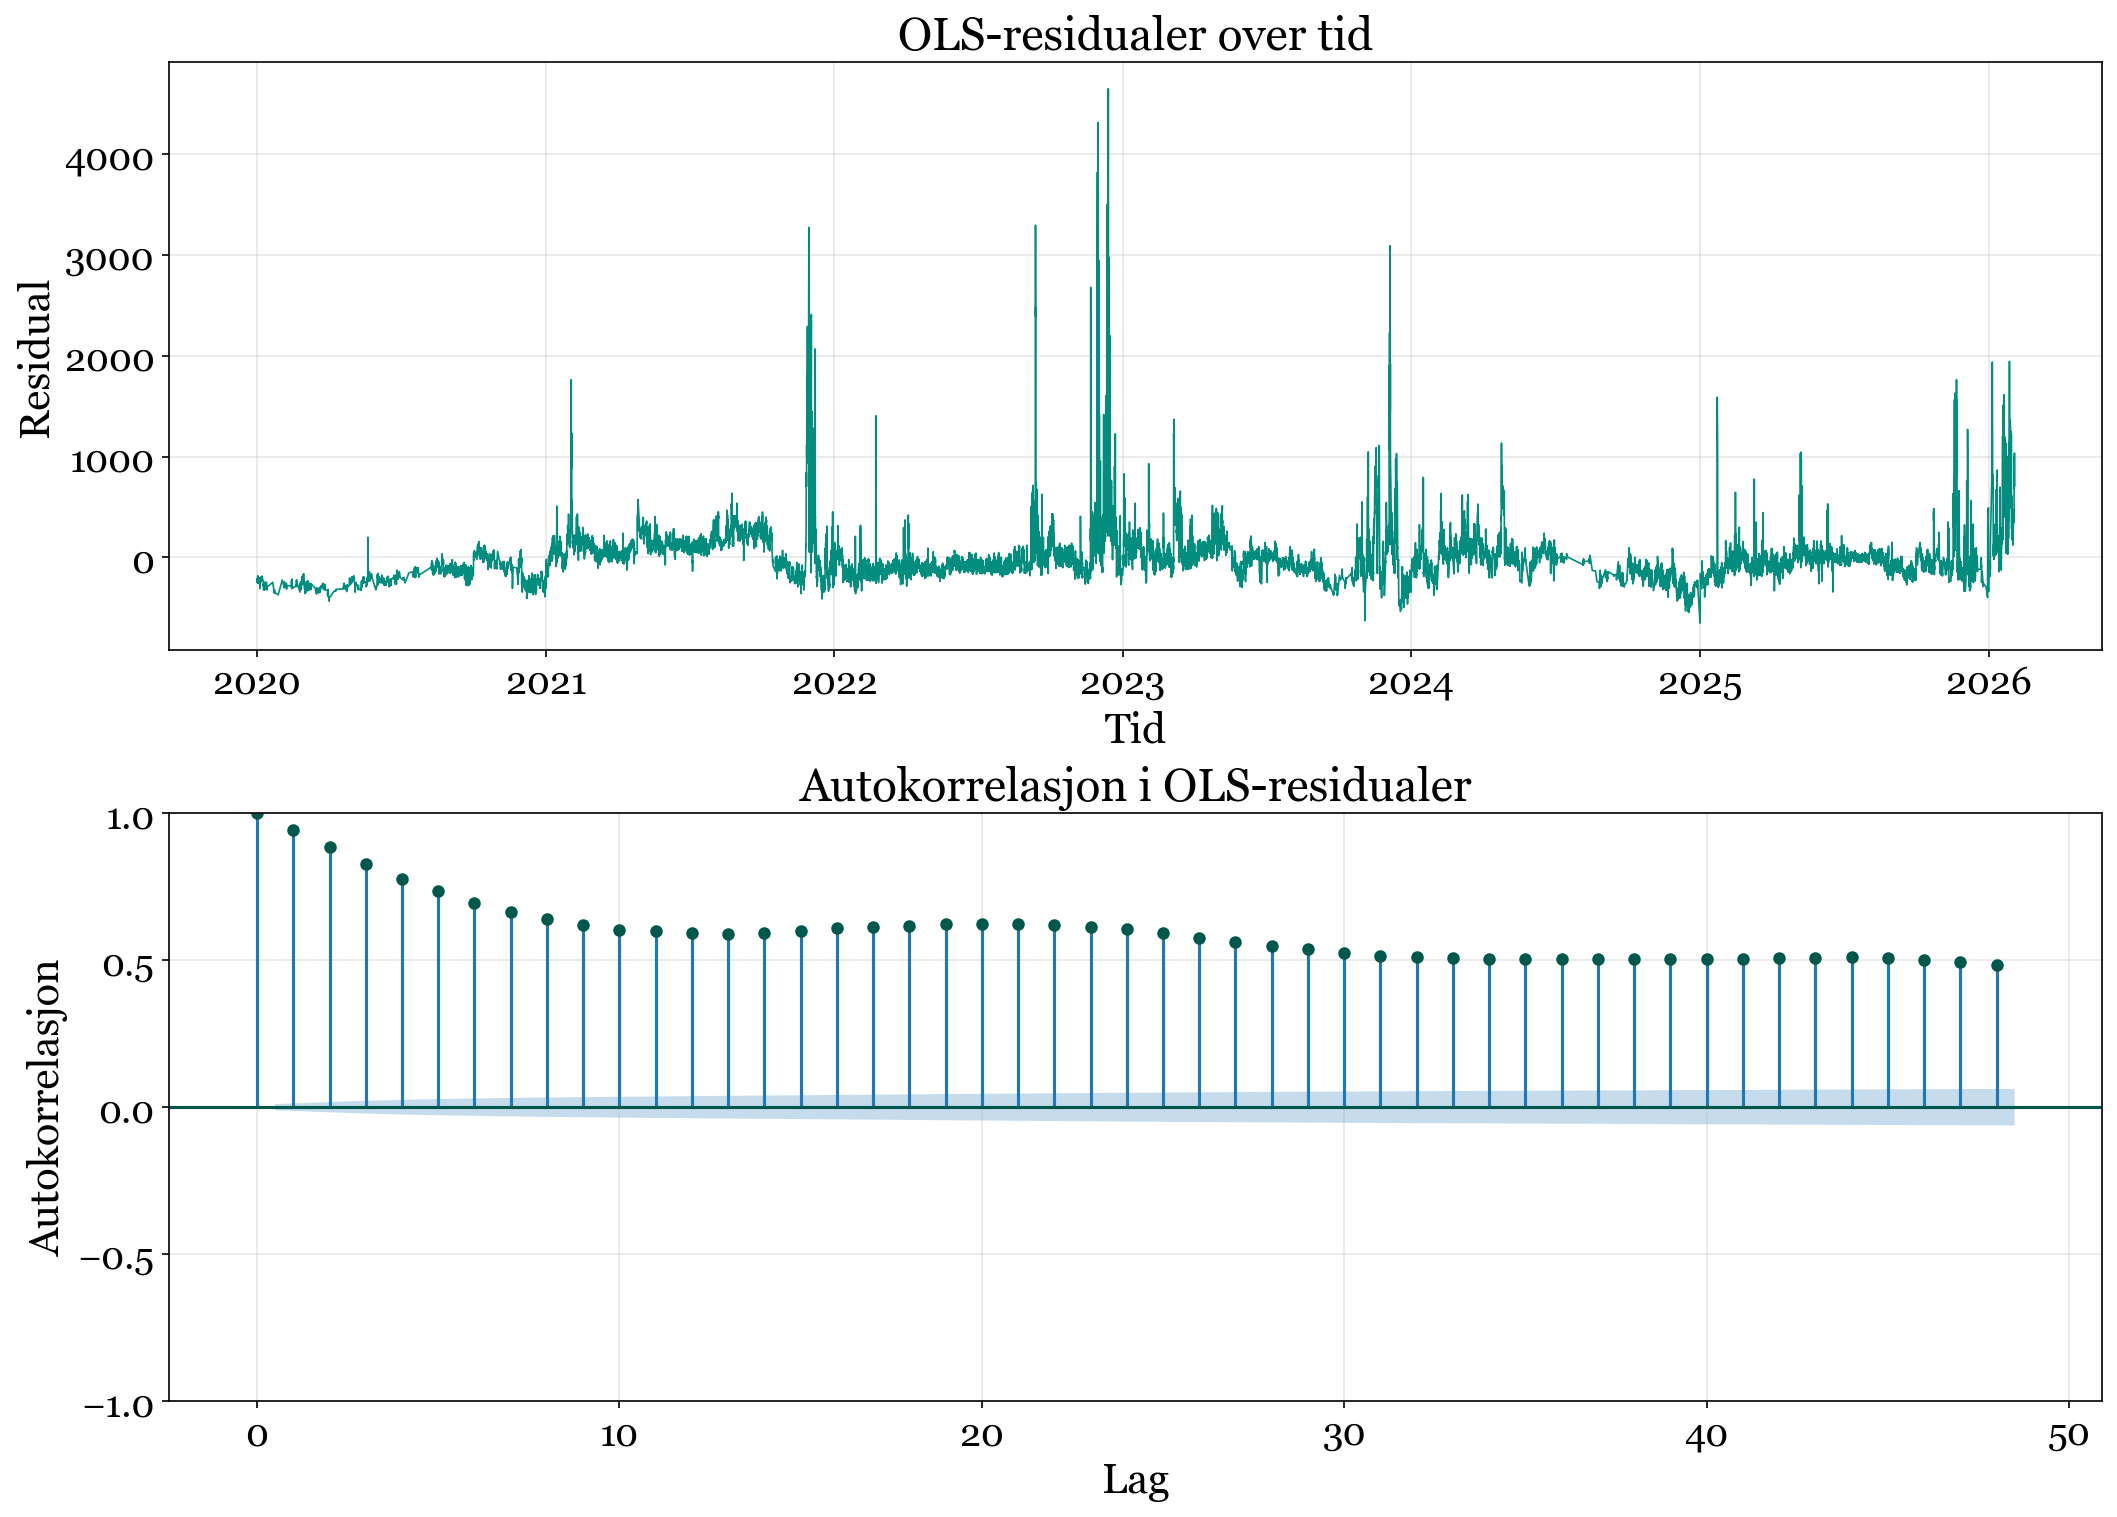

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

resid_series = pd.Series(ols_model.resid, index=df_ols.index)
axes[0].plot(resid_series.index, resid_series.values, color=C1, linewidth=0.8)
axes[0].set_title("OLS-residualer over tid")
axes[0].set_xlabel("Tid")
axes[0].set_ylabel("Residual")

plot_acf(resid_series, lags=48, ax=axes[1], color=C3)
axes[1].set_title("Autokorrelasjon i OLS-residualer")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Autokorrelasjon")

plt.savefig(os.path.join(FIG_PATH, "section_02_ols_residualdiagnostikk.pdf"), bbox_inches="tight")
plt.show()

## 3. Endogenitet og instrumentstyrke

Vi bruker en kontrollfunksjonstest for å undersøke om `cons_NO4` oppfører seg som en endogen regressors i prisligningen. Kandidatinstrumentene er temperatur og nedbør. Disse kan være relevante for forbruk, men de må fortsatt forsvares teoretisk med hensyn til eksogenitet.

In [6]:
instrument_cols = ["temp_NO4", "precip_NO4"]
exog_cols = [col for col in base_features if col != "cons_NO4"]

cf_results = control_function_endogeneity_test(
    df=df_iso,
    y_col=TARGET,
    endog_col="cons_NO4",
    instrument_cols=instrument_cols,
    exog_cols=exog_cols,
    structural_cov_type="HAC",
    hac_lags=24,
)

display(cf_results["first_stage_summary"].round(4))
display(cf_results["instrument_table"].round(4))
display(cf_results["endogeneity_test"].round(4))

cf_results["first_stage_summary"].to_csv(f"{INTERMEDIATE_DIR}diagnostics_first_stage_summary.csv", index=False)
cf_results["instrument_table"].to_csv(f"{INTERMEDIATE_DIR}diagnostics_first_stage_instruments.csv", index=False)
cf_results["endogeneity_test"].to_csv(f"{INTERMEDIATE_DIR}diagnostics_endogeneity_test.csv", index=False)

,Test,F-statistikk,p-verdi,N,R²
0,Førstesteg F-test (ekskluderte instrumenter),367.5347,0.0,34284,0.8387


,Variabel,Koeffisient,t-verdi,p-verdi
0,temp_NO4,-23.2267,-26.0719,0.0
1,precip_NO4,-4.0100,-5.9446,0.0


,Test,Koeffisient,t-verdi,p-verdi,N
0,Kontrollfunksjon (residualledd),-0.481,-8.5552,0.0,34284


## 4. Enkel funksjonsform og ikke-linearitet

Til slutt tester vi om lineær OLS blir forbedret av enkle ikke-lineære ledd. Her ser vi på interaksjon mellom forbruk og magasinavvik, samt et kvadratledd for forbruk. Dette er en enkel sjekk som kan støtte den metodiske rollen til XGBoost og regimesensitive modeller.

In [7]:
df_iso_ff = df_iso.copy()
df_iso_ff["cons_x_fill"] = df_iso_ff["cons_NO4"] * df_iso_ff["fill_avvik"]
df_iso_ff["cons_sq"] = df_iso_ff["cons_NO4"] ** 2

candidate_specs = {
    "Lineær benchmark": [],
    "+ forbruk × magasinavvik": ["cons_x_fill"],
    "+ kvadratledd for forbruk": ["cons_sq"],
    "+ begge ledd": ["cons_x_fill", "cons_sq"],
}

functional_form_table = functional_form_comparison(
    df=df_iso_ff,
    y_col=TARGET,
    base_features=base_features,
    candidate_specs=candidate_specs,
    hac_lags=24,
)

display(functional_form_table.round(4))
functional_form_table.to_csv(f"{INTERMEDIATE_DIR}diagnostics_functional_form.csv", index=False)

,Spesifikasjon,N,R²,AIC,BIC,RESET p-verdi
0,+ begge ledd,34916,0.3140,482574.0245,482912.4525,0.0
1,+ kvadratledd for forbruk,34916,0.3138,482579.4402,482909.4075,0.0
2,+ forbruk × magasinavvik,34916,0.2888,483828.7641,484158.7314,0.0
3,Lineær benchmark,34916,0.2886,483837.1409,484158.6475,0.0
